# Task 2: Exploratory Data Analysis & Data Characterization

Operates on the partitioned Parquet store written by `01_data_handling.ipynb`.
Only the three target areas plus a precomputed per-area totals series are loaded
into memory — the full ~2 GB aggregated dataset is never materialised.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import (
    load_area_from_parquet, total_traffic_per_area,
    get_area_series, get_top_traffic_area,
)
from src.eda.plots import (
    plot_traffic_pdf, plot_time_series_three_areas, plot_traffic_heatmap,
)
from src.eda.stats import adf_test, rolling_statistics, decompose_series, plot_acf_pacf

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
FIGURES_DIR  = '../outputs/figures/'
PARQUET_DIR  = '../data/processed/milan_traffic_parquet/'
TOTALS_PATH  = '../data/processed/total_per_area.parquet'
os.makedirs(FIGURES_DIR, exist_ok=True)

## 2.1 Identify the three target areas

If the cached totals file exists (written by notebook 01) we reuse it; otherwise
we recompute it via a streaming scan of the Parquet store.

In [2]:
if os.path.exists(TOTALS_PATH):
    totals = pd.read_parquet(TOTALS_PATH).iloc[:, 0]
    totals.name = 'total_internet_traffic'
    totals.index = totals.index.astype('int32')
    print(f'Loaded cached totals: {len(totals):,} areas')
else:
    totals = total_traffic_per_area(PARQUET_DIR)
    totals.to_frame().to_parquet(TOTALS_PATH)
    print(f'Computed totals from scratch: {len(totals):,} areas')

top_area = int(totals.idxmax())
print(f'Area with highest 2-month traffic: square_id = {top_area} '
      f'(total = {totals.max():.2e})')

TARGET_AREAS = {
    f'Area_{top_area}_TopTraffic': top_area,
    'Area_4159': 4159,
    'Area_4556': 4556,
}
print('Target areas:', TARGET_AREAS)

Loaded cached totals: 10,000 areas
Area with highest 2-month traffic: square_id = 5161 (total = 1.27e+07)
Target areas: {'Area_5161_TopTraffic': 5161, 'Area_4159': 4159, 'Area_4556': 4556}


## 2.2 PDF of total traffic across all 10,000 areas

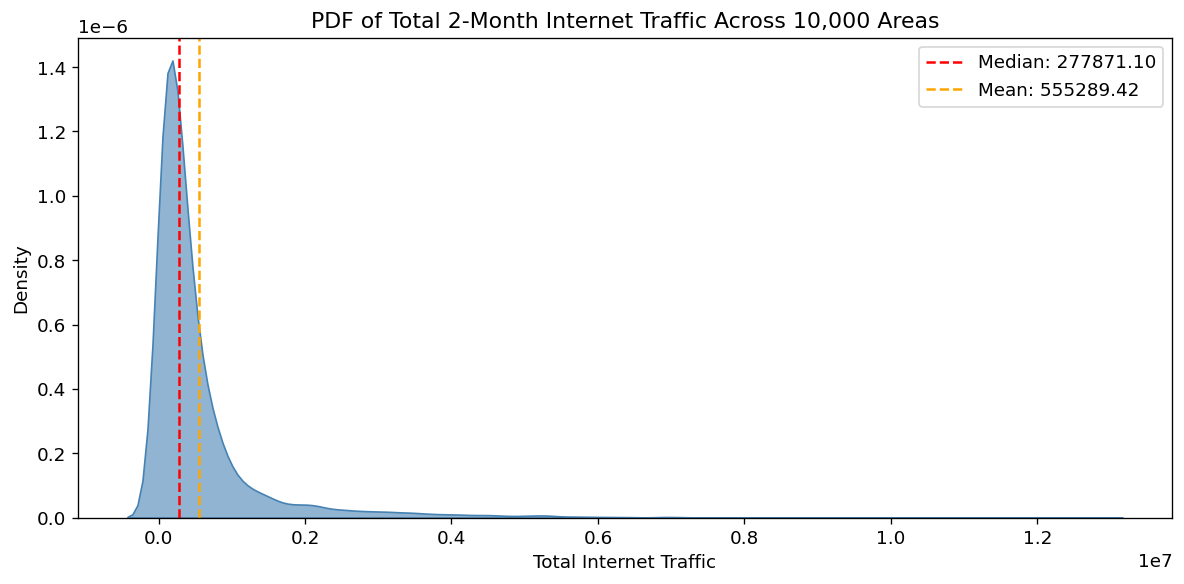

Distribution summary:
count    1.000000e+04
mean     5.552894e+05
std      8.925957e+05
min      2.136265e+02
25%      1.181020e+05
50%      2.778711e+05
75%      5.778956e+05
max      1.274006e+07
Name: total_internet_traffic, dtype: float64
Skewness : 4.265
Kurtosis : 25.516


In [3]:
fig = plot_traffic_pdf(totals, save_path=FIGURES_DIR+'pdf_total_traffic.png')
plt.show()

print('Distribution summary:')
print(totals.describe())
print(f'Skewness : {totals.skew():.3f}')
print(f'Kurtosis : {totals.kurt():.3f}')

**Discussion.** Network traffic across the 10,000 areas is typically *heavily
right-skewed*: a long tail of high-traffic cells (city centre, transport hubs,
Politecnico, San Siro) coexists with a dense mass of low-traffic suburban /
peripheral cells. Reflect on the skewness/kurtosis values above and connect them
to Milan's urban geography.

## 2.3 Time series of the three target areas (first two weeks)

Only the three areas are read from disk.

Loaded 26,784 rows for 3 areas (date range: 2013-10-31 23:00:00 → 2014-01-01 22:50:00)


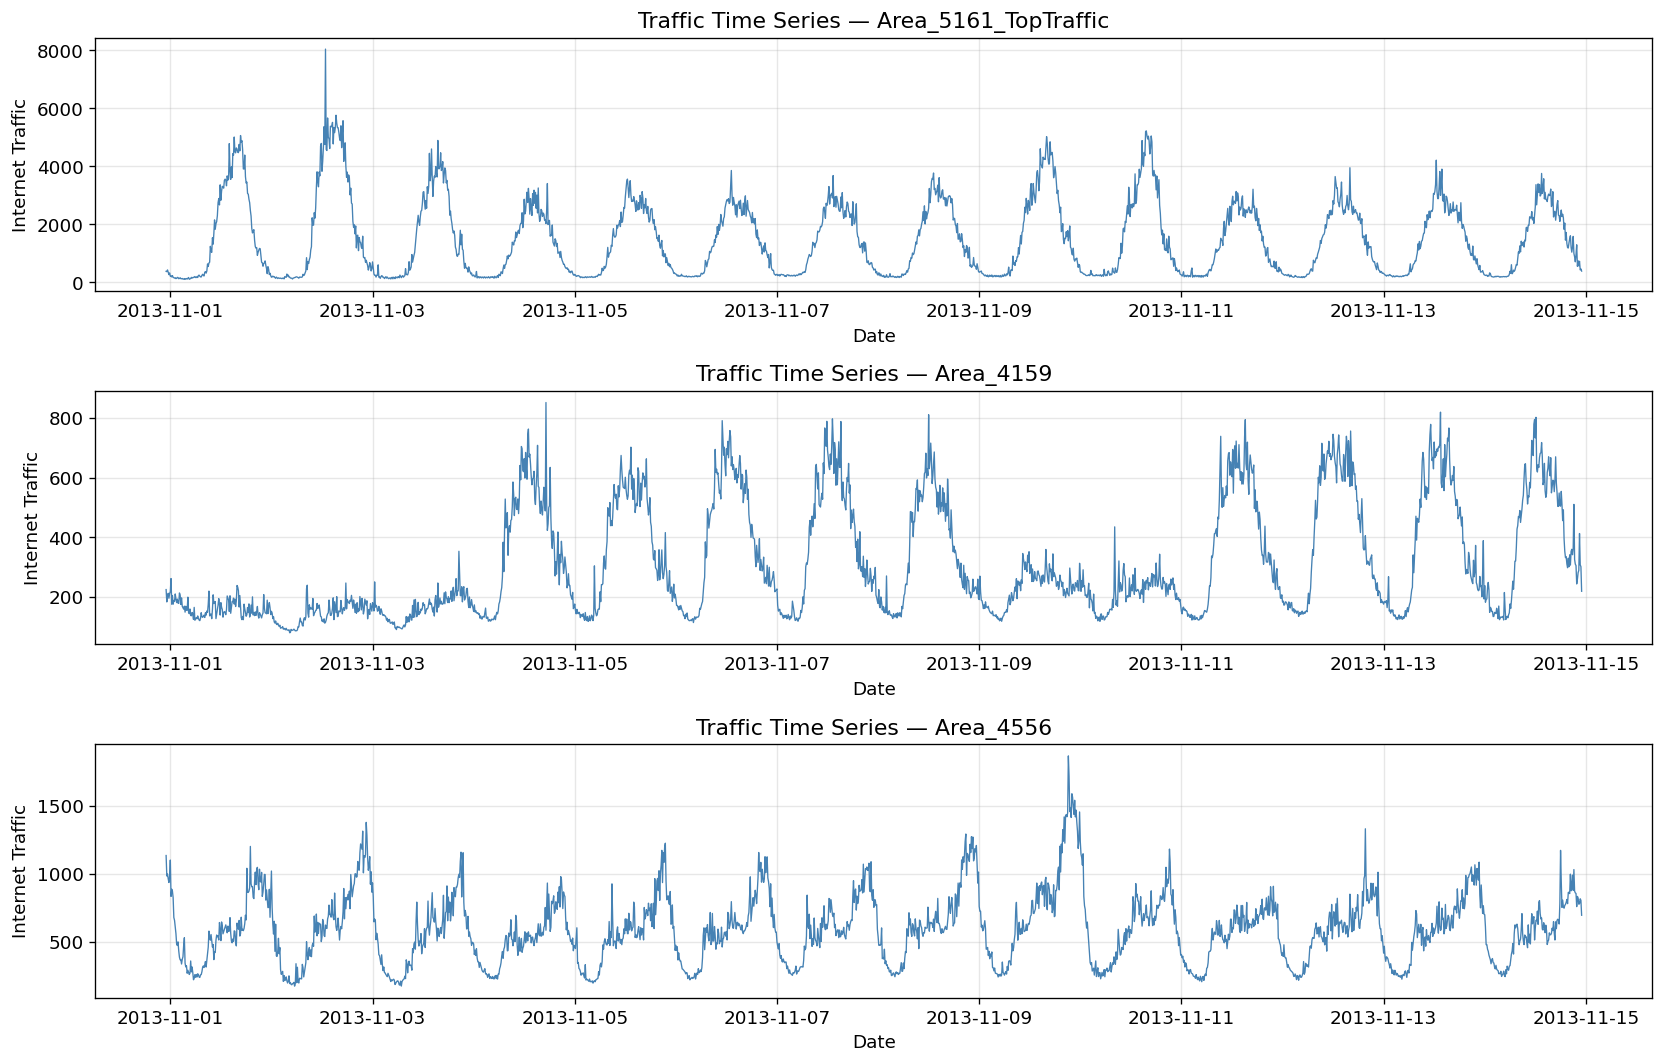

In [4]:
df_3 = load_area_from_parquet(PARQUET_DIR, list(TARGET_AREAS.values()))
df_3['datetime'] = pd.to_datetime(df_3['time_interval'], unit='ms')
print(f'Loaded {len(df_3):,} rows for {df_3["square_id"].nunique()} areas '
      f'(date range: {df_3.datetime.min()} → {df_3.datetime.max()})')

series_dict = {label: get_area_series(df_3, sq_id)
               for label, sq_id in TARGET_AREAS.items()}

fig = plot_time_series_three_areas(
    series_dict, two_weeks_only=True,
    save_path=FIGURES_DIR+'time_series_three_areas.png',
)
plt.show()

**Discussion.** Comment on (i) the shared daily rhythm — morning ramp, midday
plateau, evening peak, overnight trough — visible in all three areas, (ii) the
magnitude gap between the top-traffic cell and the other two, and (iii) any
weekday-vs-weekend contrast.

## 2.4 Stationarity (rolling stats + ADF)

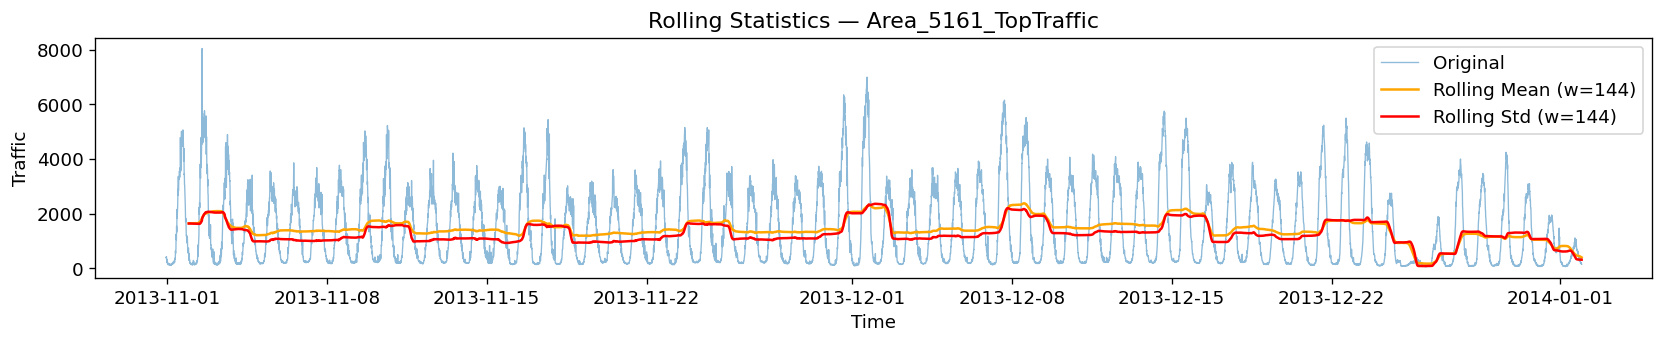


── ADF Test: Area_5161_TopTraffic ──
  ADF Statistic : -19.0319
  p-value       : 0.0000
  Critical (1%) : -3.4311
  Critical (5%) : -2.8619
  Critical (10%) : -2.5669
  → STATIONARY at 5% level


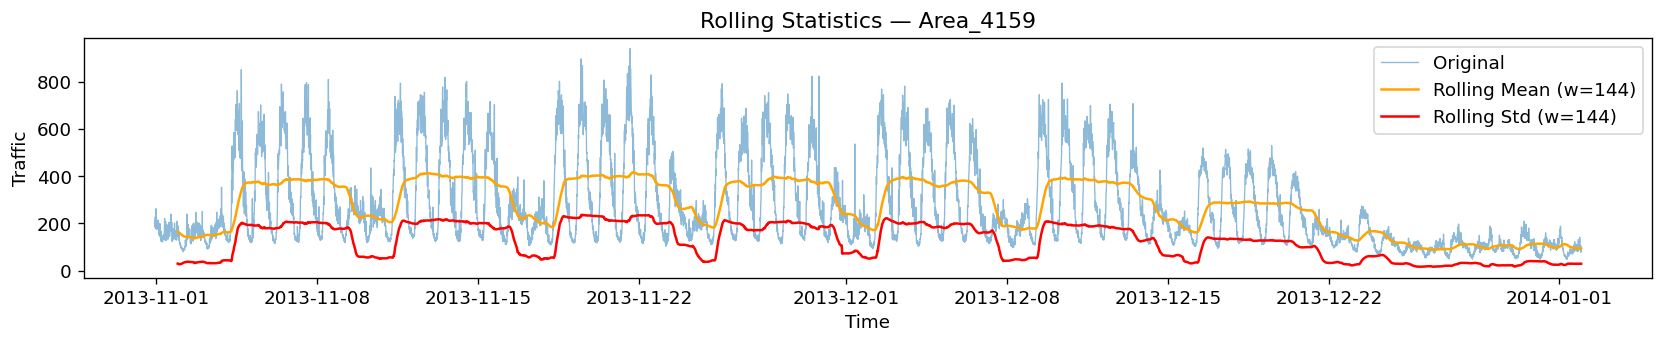


── ADF Test: Area_4159 ──
  ADF Statistic : -12.8625
  p-value       : 0.0000
  Critical (1%) : -3.4311
  Critical (5%) : -2.8619
  Critical (10%) : -2.5669
  → STATIONARY at 5% level


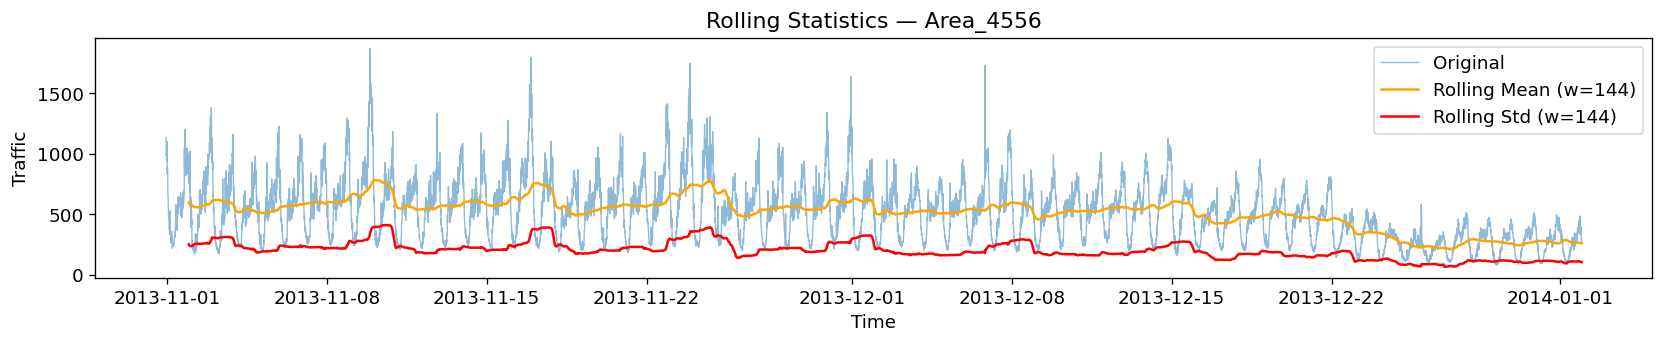


── ADF Test: Area_4556 ──
  ADF Statistic : -14.1958
  p-value       : 0.0000
  Critical (1%) : -3.4311
  Critical (5%) : -2.8619
  Critical (10%) : -2.5669
  → STATIONARY at 5% level


In [5]:
adf_results = {}
for label, series in series_dict.items():
    fig, ax = plt.subplots(figsize=(14, 3))
    rolling_statistics(series, window=144, ax=ax, title=label)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR+f'rolling_stats_{label}.png', dpi=120)
    plt.show()
    adf_results[label] = adf_test(series, title=label)

**Discussion.** Rolling-mean drift indicates a non-constant level (weekly
modulation, sporadic events). ADF p-values usually reject the unit-root null
for this series at 5 %, but the strong seasonality means a *seasonal*
differencing step is still useful before SARIMA fitting.

## 2.5 Seasonal decomposition (top area, first two weeks)

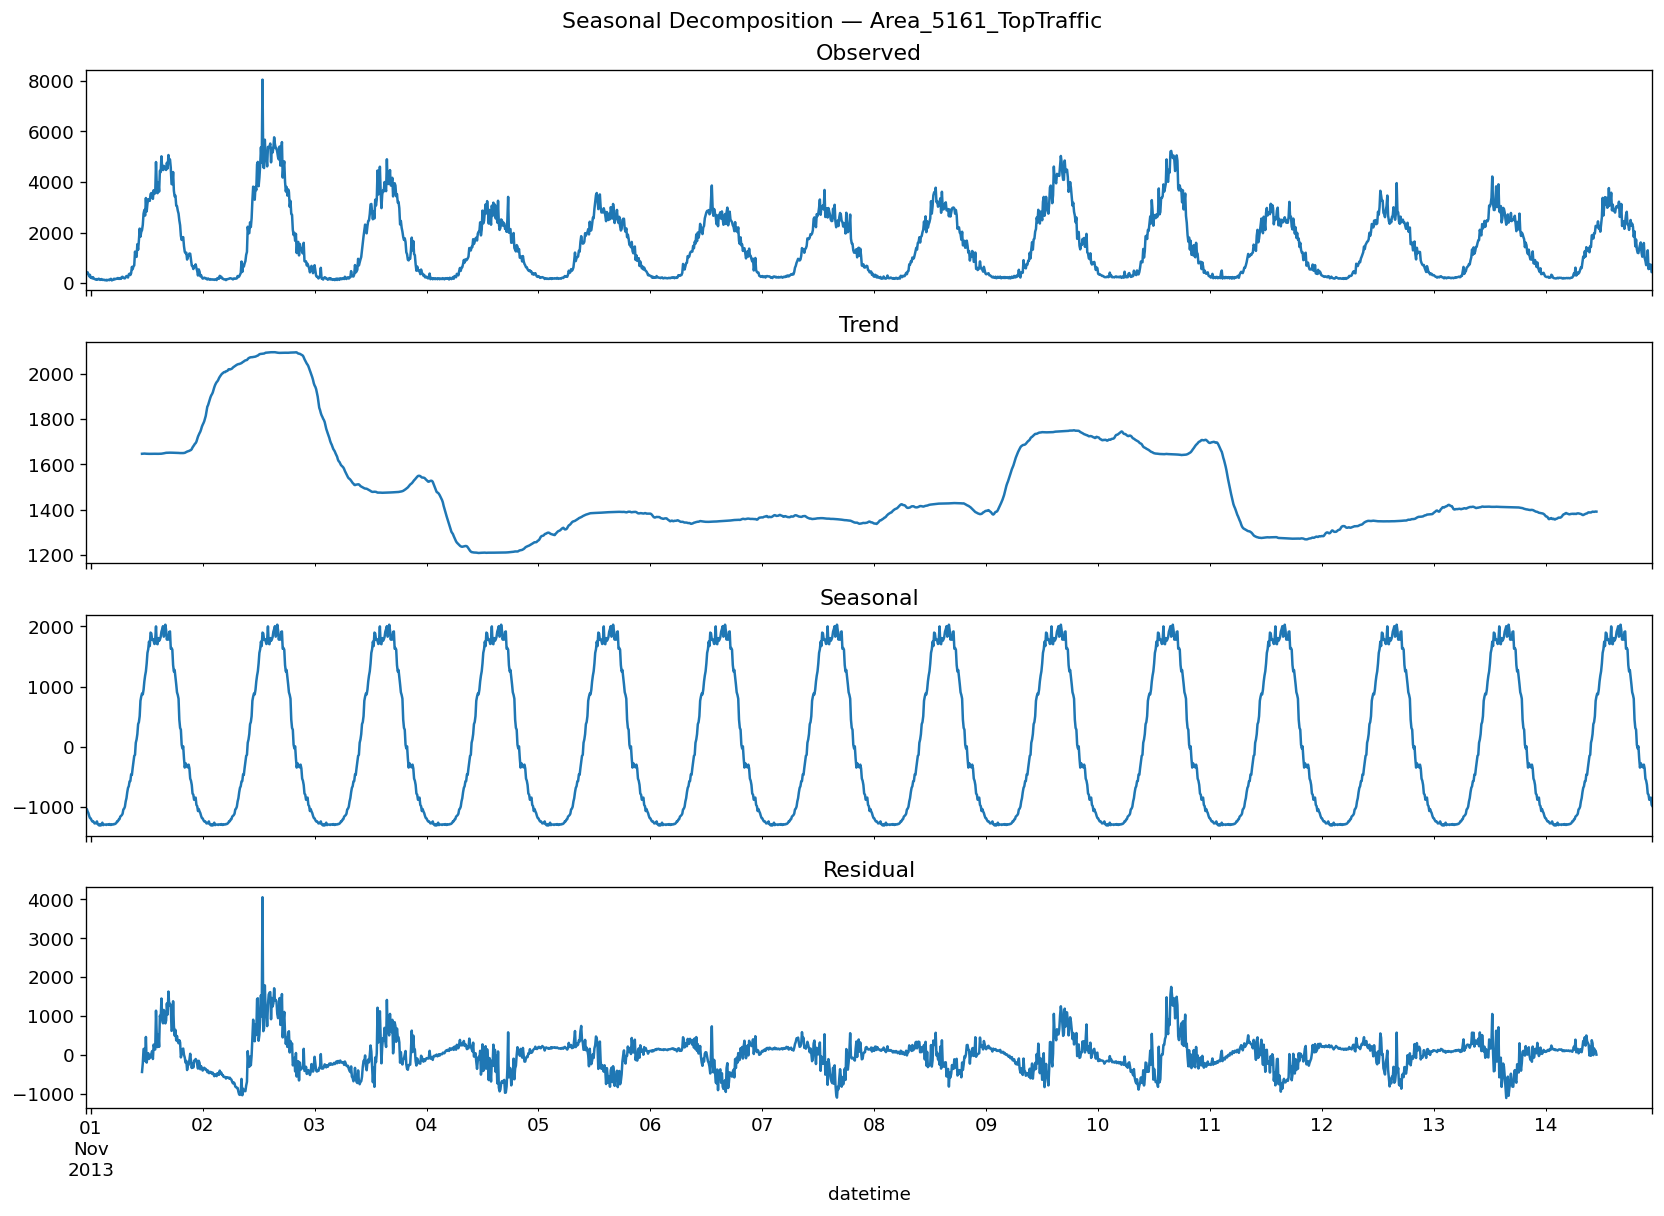

In [6]:
top_series = series_dict[next(iter(series_dict))]
two_weeks  = top_series.iloc[:144*14]
fig, result = decompose_series(two_weeks, period=144, model='additive')
plt.suptitle(f'Seasonal Decomposition — {next(iter(series_dict))}', y=1.01)
plt.savefig(FIGURES_DIR+'decomposition_top_area.png', dpi=120, bbox_inches='tight')
plt.show()

**Discussion.** Trend is roughly flat over two weeks; the seasonal component
is a clean daily cycle (period = 144 × 10 min); residuals concentrate around
occasional spikes (events, holidays, network anomalies).

## 2.6 ACF & PACF

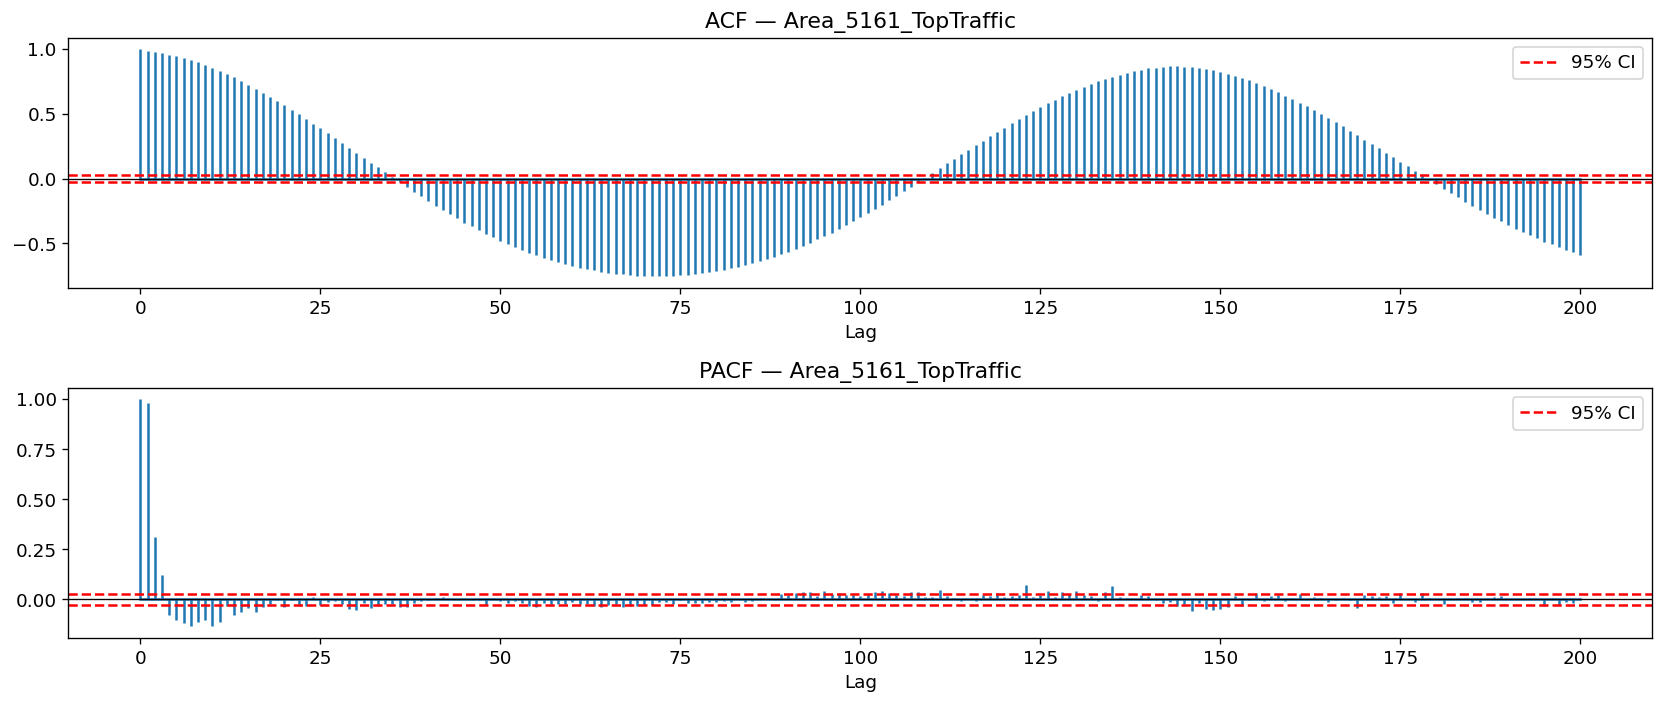

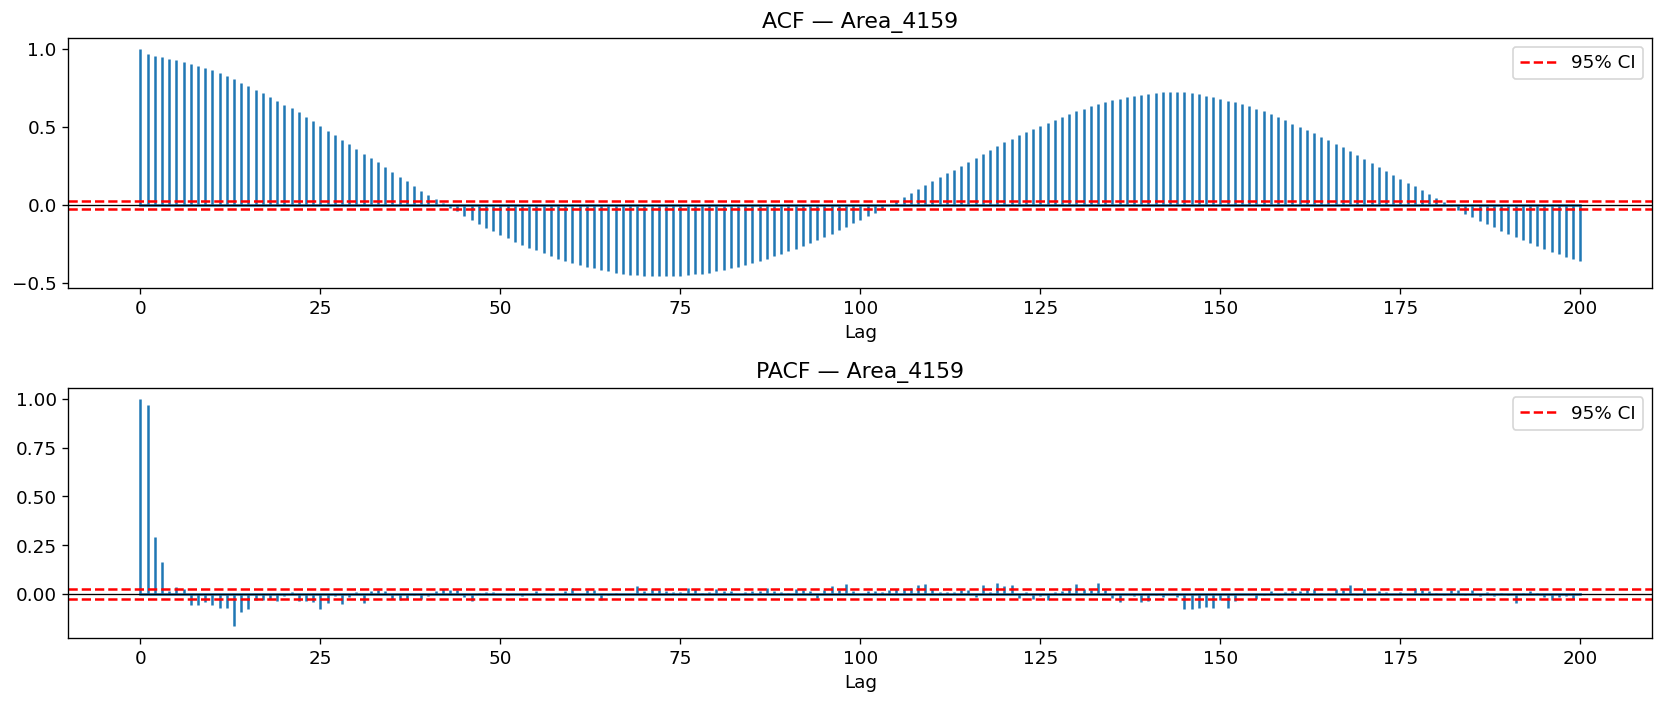

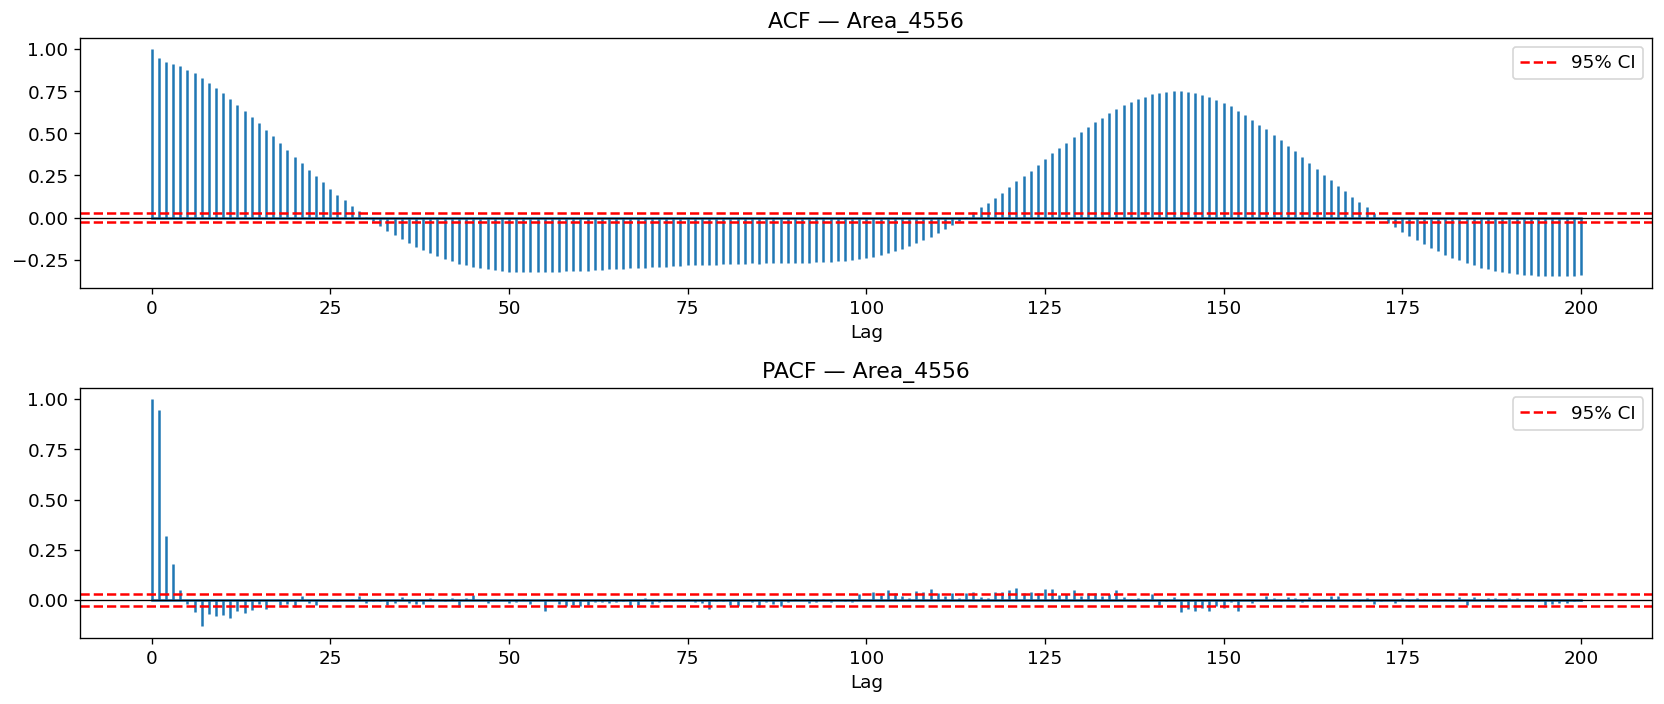

In [7]:
for label, series in series_dict.items():
    fig = plot_acf_pacf(series.iloc[:5000], lags=200, title=label)
    plt.savefig(FIGURES_DIR+f'acf_pacf_{label}.png', dpi=120)
    plt.show()

**Discussion.** Strong ACF lobe at lag = 144 confirms the 24 h cycle; the PACF
cutoff at low lags (1–3) suggests a low AR order for SARIMA's non-seasonal part.

## 2.7 Spatial heatmap (no full-dataset load)

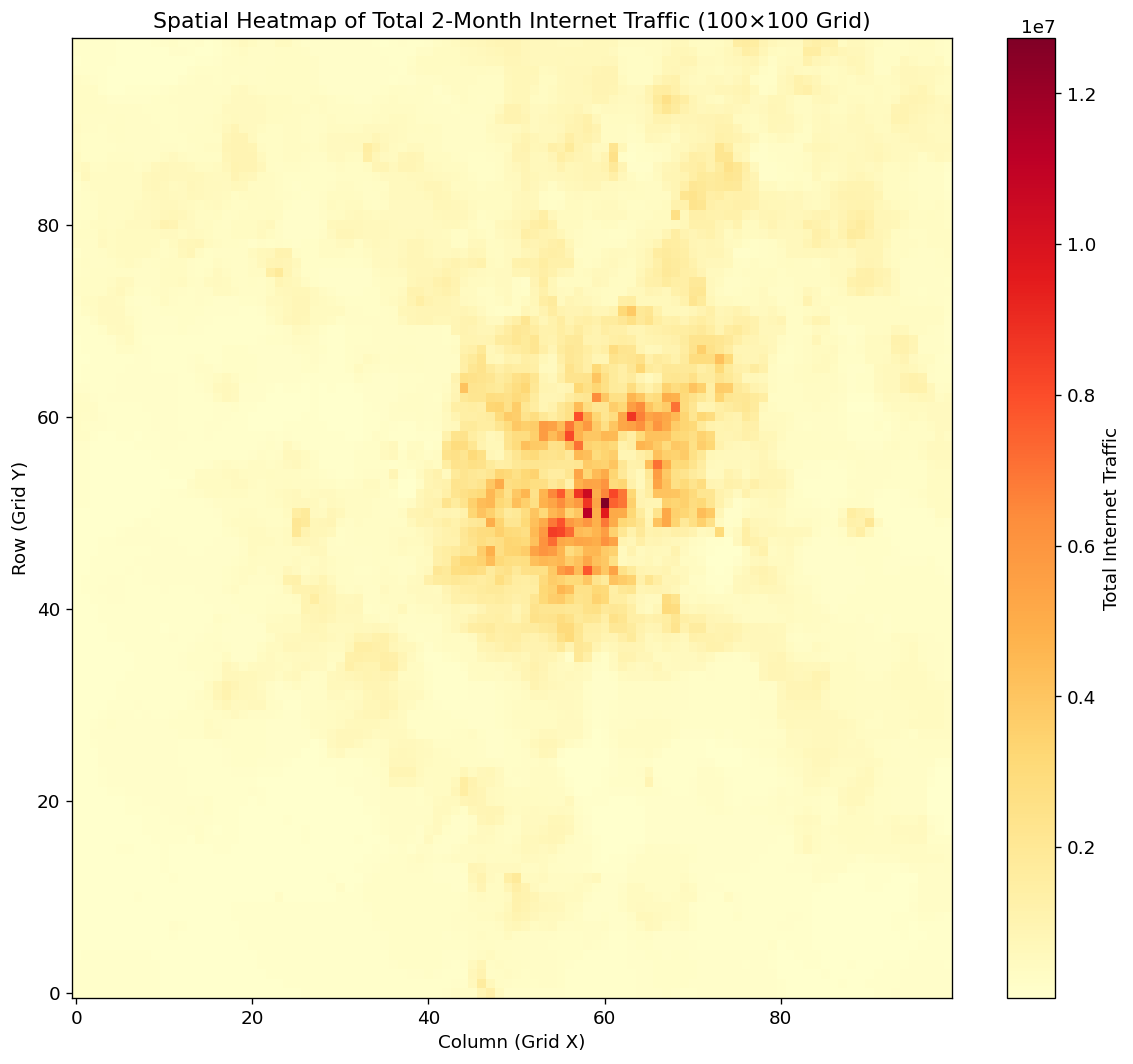

In [8]:
fig = plot_traffic_heatmap(totals, save_path=FIGURES_DIR+'spatial_heatmap.png')
plt.show()

**Discussion.** Hot spots concentrate in the centre of the grid (Duomo and
surrounding business districts), with secondary peaks at transport hubs and
stadium areas. The 100×100 tessellation cleanly separates dense central cells
from sparsely populated periphery.

## 2.8 Anomalies / outliers (top area)

Outliers (|z|>3): 51  (0.57% of samples)
datetime
2013-11-02 12:50:00    8044.070801
2013-12-01 15:50:00    6995.386719
2013-12-01 15:40:00    6753.289551
2013-12-01 15:20:00    6736.913574
2013-12-01 15:30:00    6667.623535
2013-12-01 16:00:00    6663.225098
2013-12-01 15:00:00    6550.888184
2013-12-01 15:10:00    6548.403320
2013-12-01 17:00:00    6442.487793
2013-12-01 16:20:00    6412.843262
Name: area_5161, dtype: float32


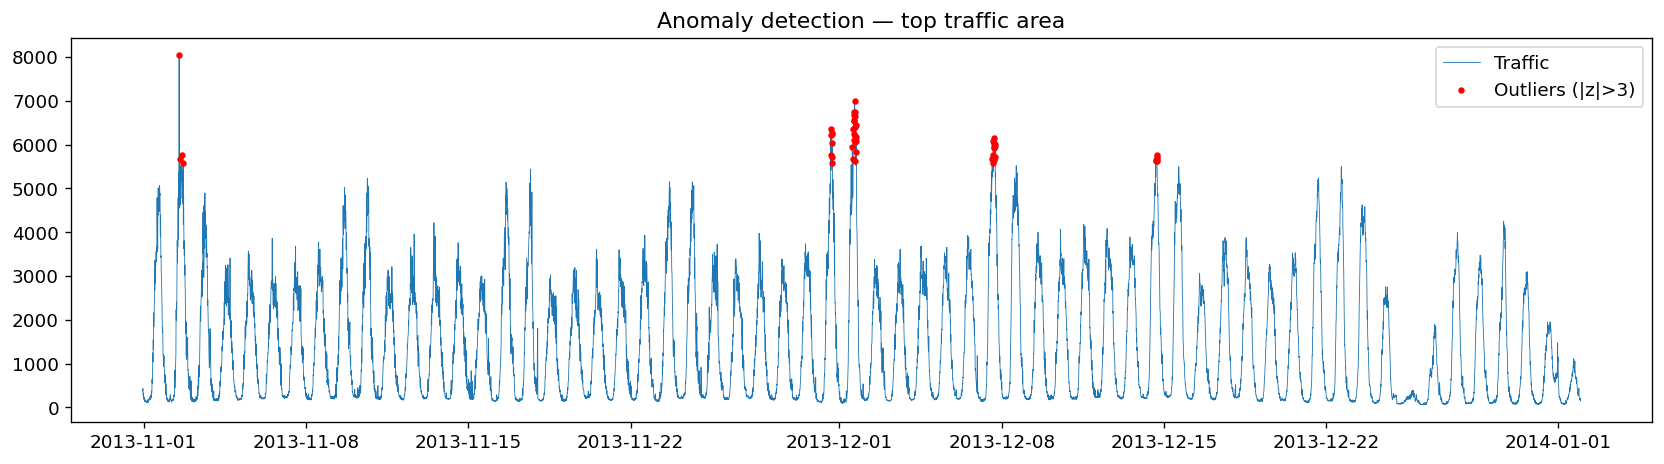

In [9]:
s = top_series
z = (s - s.mean()) / s.std()
outliers = s[z.abs() > 3]
print(f'Outliers (|z|>3): {len(outliers):,}  '
      f'({100*len(outliers)/len(s):.2f}% of samples)')
print(outliers.sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s, linewidth=0.5, label='Traffic')
ax.scatter(outliers.index, outliers.values, color='red', s=8, zorder=5,
           label='Outliers (|z|>3)')
ax.set_title('Anomaly detection — top traffic area')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR+'anomalies_top_area.png', dpi=120)
plt.show()

**Discussion.** Outliers cluster around event-likely dates (e.g., football
matches at San Siro for the relevant cells, public holidays such as the
Immacolata on 8 December, and the run-up to Christmas in the test week).
Worth flagging which (if any) fall inside Dec 16–22 — those will be the
hardest forecast points in Task 3.